In [17]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver

In [18]:
load_dotenv()
model= ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.5,
)

In [19]:
class jokestate(TypedDict):
    topic : str
    joke : str
    explanation :str 

In [20]:
def generate_joke(state:jokestate):
    prompt=f"generate a joke on the topic {state['topic']}"
    response=model.invoke(prompt).content

    return {'joke':response}

In [21]:
def explain_joke(state:jokestate):
    prompt=f"explain the joke {state['joke']} for the topic {state['topic']}"
    response=model.invoke(prompt).content

    return {'explanation':response}

In [22]:
graph=StateGraph(jokestate)

graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer=InMemorySaver()

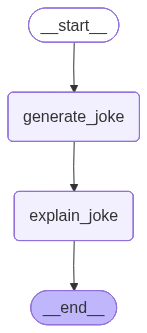

In [23]:
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [24]:
config1={"configurable":{'thread_id':"1"}}
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A delicious joke about pizza. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and creative way. In everyday language, "feeling crusty" means being irritable, grumpy, or in a bad mood.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. **Emotional state**: The pizza is in a bad mood, so it\'s feeling grumpy or irritable, which is what "crusty" typically means.\n2. **Physical characteristic**: A pizza has a crust, which is the outer layer of the pizza. So, in this case, "crusty" also refers to the pizza\'s physical composition.\n\nThe joke relies on this wordplay to create humor. It\'s a lighthearted and cheesy (pun intended) way to make people smile, and it\'s a great example of a clever pun.\n\nSo, the next time you hear someone say "I\'m feeling a little crusty," you can

In [25]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke about pizza. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and creative way. In everyday language, "feeling crusty" means being irritable, grumpy, or in a bad mood.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. **Emotional state**: The pizza is in a bad mood, so it\'s feeling grumpy or irritable, which is what "crusty" typically means.\n2. **Physical characteristic**: A pizza has a crust, which is the outer layer of the pizza. So, in this case, "crusty" also refers to the pizza\'s physical composition.\n\nThe joke relies on this wordplay to create humor. It\'s a lighthearted and cheesy (pun intended) way to make people smile, and it\'s a great example of a clever pun.\n\nSo, the next time you hear someone say "I\'m feeling a litt

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke about pizza. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and creative way. In everyday language, "feeling crusty" means being irritable, grumpy, or in a bad mood.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. **Emotional state**: The pizza is in a bad mood, so it\'s feeling grumpy or irritable, which is what "crusty" typically means.\n2. **Physical characteristic**: A pizza has a crust, which is the outer layer of the pizza. So, in this case, "crusty" also refers to the pizza\'s physical composition.\n\nThe joke relies on this wordplay to create humor. It\'s a lighthearted and cheesy (pun intended) way to make people smile, and it\'s a great example of a clever pun.\n\nSo, the next time you hear someone say "I\'m feeling a lit

In [27]:
config2={"configurable":{'thread_id':"2"}}
workflow.invoke({'topic':'pasta'},config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'A deliciously cheesy joke. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This is a classic joke setup, where we\'re expecting a typical reason why someone might not want to get married. But, of course, this is a joke about spaghetti, so we know it\'s going to be a play on words.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." Ah, the clever part! The joke relies on a double meaning of the phrase "tangled up." In a romantic relationship, "tangled up" can mean being deeply involved or entangled emotionally. But, for spaghetti, "tangled up" is also a literal possibility - the long, thin strands of pasta can easily become knotted or tangled.\n\n**The Wordplay:** The joke exploits this dual meaning of "tangled up" to create a humorous connection between th

In [28]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A deliciously cheesy joke. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This is a classic joke setup, where we\'re expecting a typical reason why someone might not want to get married. But, of course, this is a joke about spaghetti, so we know it\'s going to be a play on words.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." Ah, the clever part! The joke relies on a double meaning of the phrase "tangled up." In a romantic relationship, "tangled up" can mean being deeply involved or entangled emotionally. But, for spaghetti, "tangled up" is also a literal possibility - the long, thin strands of pasta can easily become knotted or tangled.\n\n**The Wordplay:** The joke exploits this dual meaning of "tangled up" to create a humorous co

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A deliciously cheesy joke. Let\'s break it down:\n\n**The Setup:** "Why did the spaghetti refuse to get married?" This is a classic joke setup, where we\'re expecting a typical reason why someone might not want to get married. But, of course, this is a joke about spaghetti, so we know it\'s going to be a play on words.\n\n**The Punchline:** "Because it was afraid of getting tangled up in a relationship." Ah, the clever part! The joke relies on a double meaning of the phrase "tangled up." In a romantic relationship, "tangled up" can mean being deeply involved or entangled emotionally. But, for spaghetti, "tangled up" is also a literal possibility - the long, thin strands of pasta can easily become knotted or tangled.\n\n**The Wordplay:** The joke exploits this dual meaning of "tangled up" to create a humorous c

## TIME TRAVEL

In [32]:
workflow.get_state({'configurable':{'thread_id':"1",'checkpoint_id': '1f16e100-e553-68aa-8000-80b1399db9a2'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16e100-e553-68aa-8000-80b1399db9a2'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-22T07:57:46.419421+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e100-e551-61a2-bfff-64c44be04cff'}}, tasks=(PregelTask(id='984dc18b-70f5-3a4b-a7ab-f183265cd401', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [34]:
workflow.invoke(None,{'configurable':{'thread_id':"1",'checkpoint_id': '1f16e100-e553-68aa-8000-80b1399db9a2'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. \n\nIn everyday language, "feeling crusty" is an idiom that means being irritable, grumpy, or in a bad mood. However, in the context of pizza, "crusty" has a different meaning - it refers to the crispy, outer layer of the pizza, also known as the crust.\n\nSo, in this joke, the punchline "it was feeling a little crusty" is a clever pun that connects the pizza\'s bad mood to its crust. It\'s as if the pizza is making a joke about its own crust, saying that it\'s feeling grumpy because of its crust - both the emotional state and the physical part of the pizza.\n\nThis type of wordplay is what makes the joke amusing and clever, and it\'s a great example of how language can be used creatively to make people laugh.'}

In [35]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. \n\nIn everyday language, "feeling crusty" is an idiom that means being irritable, grumpy, or in a bad mood. However, in the context of pizza, "crusty" has a different meaning - it refers to the crispy, outer layer of the pizza, also known as the crust.\n\nSo, in this joke, the punchline "it was feeling a little crusty" is a clever pun that connects the pizza\'s bad mood to its crust. It\'s as if the pizza is making a joke about its own crust, saying that it\'s feeling grumpy because of its crust - both the emotional state and the physical part of the pizza.\n\nThis type of wordplay is what makes the joke amusing and clever, and it\'s a great example of how language can be used creatively to make p

## changing state

In [39]:
workflow.update_state({'configurable':{"thread_id":"1",'checkpoint_id':'1f16e100-e553-68aa-8000-80b1399db9a2','checkpoint_ns': '', }},{'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16e10b-df09-618d-8001-487ec5f5f0b4'}}

In [40]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e10b-df09-618d-8001-487ec5f5f0b4'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-22T08:02:41.038785+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e100-e553-68aa-8000-80b1399db9a2'}}, tasks=(PregelTask(id='0948f0a3-1c08-2763-831b-b85126ed98f0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. \n\nIn everyday language, "feeling crusty" is an idiom that means being irritable, grum

In [41]:
workflow.invoke(None,{'configurable':{'thread_id':"1",'checkpoint_id': '1f16e10b-df09-618d-8001-487ec5f5f0b4'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside.',
 'explanation': 'A delicious joke about samosas. Let\'s break it down:\n\nThe joke is a play on words, using the characteristics of a samosa to make a humorous comment about emotional well-being. Here\'s how it works:\n\n* "Crunchy on the outside" refers to the crispy, fried exterior of a samosa, which is a typical texture associated with this popular Indian snack.\n* "Empty on the inside" is a clever pun, as samosas are often filled with a savory filling, such as spiced potatoes, peas, and onions. However, in this joke, "empty" has a double meaning, implying that the samosa is feeling emotionally hollow or unfulfilled.\n\nThe humor comes from the unexpected twist of applying human emotions to a food item. The joke suggests that the samosa is seeking therapy because it\'s struggling with feelings of superficiality (being crunchy on the

In [42]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside.', 'explanation': 'A delicious joke about samosas. Let\'s break it down:\n\nThe joke is a play on words, using the characteristics of a samosa to make a humorous comment about emotional well-being. Here\'s how it works:\n\n* "Crunchy on the outside" refers to the crispy, fried exterior of a samosa, which is a typical texture associated with this popular Indian snack.\n* "Empty on the inside" is a clever pun, as samosas are often filled with a savory filling, such as spiced potatoes, peas, and onions. However, in this joke, "empty" has a double meaning, implying that the samosa is feeling emotionally hollow or unfulfilled.\n\nThe humor comes from the unexpected twist of applying human emotions to a food item. The joke suggests that the samosa is seeking therapy because it\'s struggling with feelings of superficiality (

## Fault tolerance